In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC


In [4]:
df = pd.read_csv('prepared_data.csv')
df

,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,FCVC,CAEC,CH2O,FAF,TUE,CALC,Age,Height,Weight,NCP,NObeyesdad
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1,1,0,1,0,21.000000,1.620000,64.000000,3.0,Normal_Weight
1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,2,1,2,3,0,1,21.000000,1.520000,56.000000,3.0,Normal_Weight
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1,1,2,1,2,23.000000,1.800000,77.000000,3.0,Normal_Weight
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2,1,1,2,0,2,27.000000,1.800000,87.000000,3.0,Overweight_Level_I
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1,1,0,0,1,22.000000,1.780000,89.800000,1.0,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2,1,1,2,1,1,20.976842,1.710730,131.408528,3.0,Obesity_Type_III
2107,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2,1,1,1,1,1,21.982942,1.748584,133.742943,3.0,Obesity_Type_III
2108,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2,1,1,1,1,1,22.524036,1.752206,133.689352,3.0,Obesity_Type_III
2109,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2,1,2,1,1,1,24.361936,1.739450,133.346641,3.0,Obesity_Type_III


In [5]:
x = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42, stratify=y)

In [7]:
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)

svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', probability=True, random_state=42)
)

rf_pipeline = make_pipeline(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
)

dt_pipeline = make_pipeline(
    DecisionTreeClassifier(random_state=42)
)

estimators = [
    ('logreg', logreg_pipeline),
    ('svm', svm_pipeline),
    ('rf', rf_pipeline),
    ('dt', dt_pipeline)
]

# Определяем метамодель
final_estimator = LogisticRegression()


In [9]:
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

stacking

,estimators,"[('logreg', ...), ('svm', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'


In [16]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'logreg__logisticregression__C': [0.1, 1, 10],
    'logreg__logisticregression__penalty': ['l2'],
    'logreg__logisticregression__solver': ['newton-cg', 'saga'],
    'svm__svc__kernel': ['linear','rbf'],
    'svm__svc__C': [0.1, 1, 10],
    'rf__randomforestclassifier__n_estimators': [50, 100],
    'rf__randomforestclassifier__max_depth': [5, 10],
    'dt__decisiontreeclassifier__max_depth': [5, 10],
    'dt__decisiontreeclassifier__min_samples_leaf': [3,5]
}

gs_stack = GridSearchCV(
    stacking,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=stratified_kfold,
    n_jobs=-1,
    verbose=1
)

gs_stack.fit(X_train, y_train)

print(f'\nЛучшие параметры: {gs_stack.best_params_}')
print(f'Лучшее качество (F1-weighted) на кросс-валидации: {gs_stack.best_score_:.4f}')

Fitting 5 folds for each of 576 candidates, totalling 2880 fits

Лучшие параметры: {'dt__decisiontreeclassifier__max_depth': 10, 'dt__decisiontreeclassifier__min_samples_leaf': 5, 'logreg__logisticregression__C': 10, 'logreg__logisticregression__penalty': 'l2', 'logreg__logisticregression__solver': 'saga', 'rf__randomforestclassifier__max_depth': 10, 'rf__randomforestclassifier__n_estimators': 50, 'svm__svc__C': 10, 'svm__svc__kernel': 'linear'}
Лучшее качество (F1-weighted) на кросс-валидации: 0.9842


In [ ]:
meta_data = gs_stack.best_estimator_.transform(X_train)

meta_df = pd.DataFrame(
    meta_data,
    columns=[f'meta_feature{i+1}' for i in range(meta_data.shape[1])]
)
meta_df

,meta_feature1,meta_feature2,meta_feature3,meta_feature4,meta_feature5,meta_feature6,meta_feature7,meta_feature8,meta_feature9,meta_feature10,...,meta_feature19,meta_feature20,meta_feature21,meta_feature22,meta_feature23,meta_feature24,meta_feature25,meta_feature26,meta_feature27,meta_feature28
0,9.830704e-05,6.121942e-03,1.161673e-01,3.570211e-03,9.348193e-06,0.113442,0.760591,0.000084,0.000242,0.002716,...,0.0,0.057034,0.690233,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.549895e-02,1.563859e-01,1.108118e-01,5.718555e-07,1.927138e-03,0.619187,0.096189,0.004299,0.004840,0.005355,...,0.0,0.862973,0.037960,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,8.087160e-01,1.765838e-01,7.812062e-08,3.567335e-12,1.517030e-12,0.014568,0.000132,0.991224,0.003744,0.001225,...,0.0,0.027316,0.024786,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.839518e-02,1.414877e-01,3.607368e-02,1.826106e-06,2.008853e-03,0.589031,0.213002,0.001473,0.040830,0.002592,...,0.0,0.612974,0.173030,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2.969060e-03,7.121561e-02,3.256068e-02,5.489303e-04,2.340338e-05,0.610240,0.282442,0.000628,0.009350,0.005824,...,0.0,0.578133,0.214935,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1578,2.990658e-12,5.176119e-08,1.477143e-01,8.510263e-01,3.494918e-04,0.000025,0.000884,0.000361,0.000350,0.000695,...,0.0,0.001340,0.022481,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1579,5.697034e-06,2.408957e-03,7.215847e-01,2.167643e-03,8.151091e-03,0.093556,0.172126,0.001366,0.001694,0.987821,...,0.0,0.092822,0.030328,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1580,7.664780e-01,2.136982e-01,5.867808e-06,2.777031e-11,1.006001e-11,0.016889,0.002929,0.889239,0.104292,0.001662,...,0.0,0.031410,0.005852,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1581,1.499960e-11,2.131838e-07,2.467549e-01,7.505177e-01,5.410062e-05,0.000116,0.002558,0.000981,0.001055,0.003322,...,0.0,0.015385,0.032356,0.0,0.0,0.0,1.0,0.0,0.0,0.0


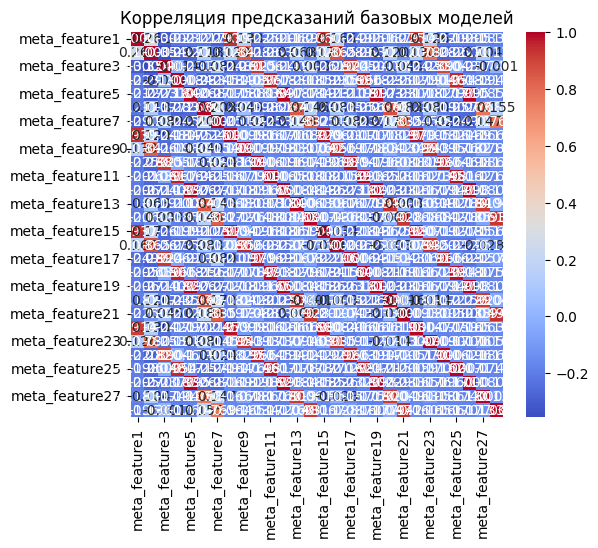

In [25]:
best_stacking_model = gs_stack.best_estimator_

meta_coefs = best_stacking_model.final_estimator_.coef_
model_names = [name for name, _ in estimators]

meta_features = best_stacking_model.transform(X_train)

plt.figure(figsize=(6, 5))
sns.heatmap(meta_df.corr(), annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Корреляция предсказаний базовых моделей')
plt.show()